# Audio Classification

This notebook converts short audio files into mel spectrograms and trains a CNN classifier on them.


In [1]:
# The small sample audio dataset used here is included in this repository.

In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import os
import time
import numpy as np
import wave
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


## Load audio paths

The CSV points to a small local audio sample dataset.


In [3]:
df = pd.read_csv('quran-recitations-for-audio-classification/files_paths.csv')
print(f"Classes : {df['Class'].unique()}")
print()
print('Number of Classes : ',len(df['Class'].unique()))
df.head()


Classes : <StringArray>
['reciter_a', 'reciter_b', 'reciter_c']
Length: 3, dtype: str

Number of Classes :  3


,FilePath,Class
0,./Dataset/reciter_a/reciter_a_0.wav,reciter_a
1,./Dataset/reciter_a/reciter_a_1.wav,reciter_a
2,./Dataset/reciter_a/reciter_a_2.wav,reciter_a
3,./Dataset/reciter_a/reciter_a_3.wav,reciter_a
4,./Dataset/reciter_a/reciter_a_4.wav,reciter_a


path ex : `/content/quran-recitations-for-audio-classification/Dataset/Dataset/AbdulBari_Althubaity/abdulbari_001.wav`

In [4]:
df['FilePath'] = df['FilePath'].apply(lambda p: os.path.join('quran-recitations-for-audio-classification', p[2:] if p.startswith('./') else p))
print(df['FilePath'][0])


quran-recitations-for-audio-classification\Dataset/reciter_a/reciter_a_0.wav


In [5]:
print(f"Data shape : {df.shape}")
print(f"Number of classes : {len(df['Class'].unique())}")
print(f"Data distribution : \n{df['Class'].value_counts()}")

Data shape : (15, 2)
Number of classes : 3
Data distribution : 
Class
reciter_a    5
reciter_b    5
reciter_c    5
Name: count, dtype: int64


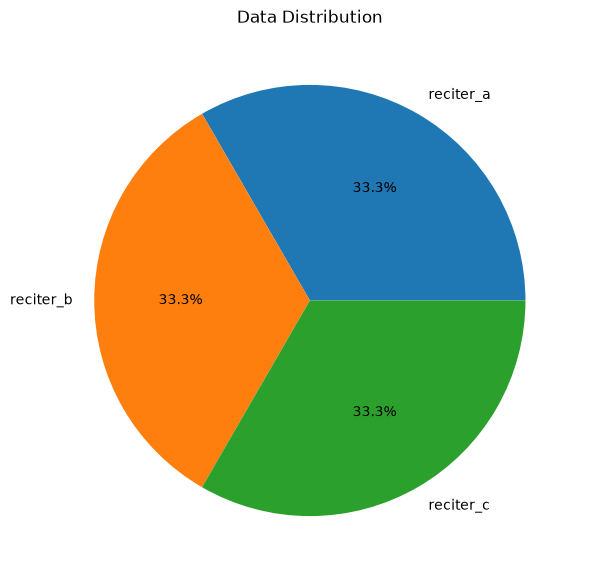

In [6]:
plt.figure(figsize=(10, 7))
plt.pie(df['Class'].value_counts(), labels=df['Class'].unique(), autopct='%1.1f%%')
plt.title('Data Distribution')
plt.show()

In [7]:
## splitting the data train 70% -- val 15% -- test 15%


train = df.sample(frac = 0.7, random_state=42)
test = df.drop(train.index)
val = test.sample(frac = 0.5, random_state=42)
test = test.drop(val.index)

print(f"Train shape : {train.shape}")
print(f"Val shape : {val.shape}")
print(f"Test shape : {test.shape}")

Train shape : (10, 2)
Val shape : (2, 2)
Test shape : (3, 2)


In [8]:
label_encoder = LabelEncoder()
label_encoder.fit(df['Class'])

class Data(Dataset):
  def __init__(self, df):
    self.df = df
    self.labels = torch.tensor(label_encoder.transform(df['Class']), dtype=torch.long)
    self.audios = [torch.Tensor(self.get_specrogram(path)).unsqueeze(0).type(torch.FloatTensor) for path in df['FilePath']]

  def __len__(self):
    return self.df.shape[0]

  def __getitem__(self, idx):
    audio = self.audios[idx].to(device)
    label = self.labels[idx].to(device)
    return audio, label

  def get_specrogram(self, path):
    img_height = 128
    img_width = 256

    with wave.open(path, 'rb') as audio_file:
      sr = audio_file.getframerate()
      frames = audio_file.readframes(audio_file.getnframes())

    signal = np.frombuffer(frames, dtype=np.int16).astype(np.float32) / 32768.0
    if len(signal) < 512:
      signal = np.pad(signal, (0, 512 - len(signal)))

    frame_size = 512
    hop = 256
    windows = []
    for start_idx in range(0, len(signal) - frame_size + 1, hop):
      frame = signal[start_idx:start_idx + frame_size] * np.hanning(frame_size)
      spectrum = np.abs(np.fft.rfft(frame))[:img_height]
      windows.append(spectrum)

    spec = np.array(windows).T
    spec = np.log1p(spec)
    spec = spec / (spec.max() + 1e-8)

    x_old = np.linspace(0, 1, spec.shape[1])
    x_new = np.linspace(0, 1, img_width)
    resized = np.vstack([np.interp(x_new, x_old, row) for row in spec])
    return resized

In [9]:
train_data = Data(train)
val_data = Data(val)
test_data = Data(test)
print(f"Train shape : {len(train_data)}")
print(f"Val shape : {len(val_data)}")
print(f"Test shape : {len(test_data)}")

Train shape : 10
Val shape : 2
Test shape : 3


In [10]:
LR = 1e-3
BATCH_SIZE = 64
EPOCHS = 2

In [11]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

## Train an audio CNN

The CNN learns from spectrograms instead of raw waveforms.


In [12]:
class Zen(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
    self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
    self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
    self.pooling = nn.MaxPool2d(kernel_size=2, stride=2)
    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()

    self.linear1 = nn.Linear(in_features=64*16*32, out_features=4096)
    self.linear2 = nn.Linear(in_features=4096, out_features=2048)
    self.linear3 = nn.Linear(in_features=2048, out_features=1024)
    self.linear4 = nn.Linear(in_features=1024, out_features=512)

    self.output = nn.Linear(in_features=512, out_features=len(df['Class'].unique()))

    self.dropout = nn.Dropout(0.4)

  def forward(self, X):
    X = self.relu(self.conv1(X))
    X = self.pooling(X)

    X = self.relu(self.conv2(X))
    X = self.pooling(X)

    X = self.relu(self.conv3(X))
    X = self.pooling(X)

    X = self.flatten(X)

    X = self.relu(self.linear1(X))
    X = self.dropout(X)

    X = self.relu(self.linear2(X))
    X = self.dropout(X)

    X = self.relu(self.linear3(X))
    X = self.dropout(X)

    X = self.relu(self.linear4(X))
    X = self.dropout(X)

    X = self.output(X)

    return X

model = Zen().to(device)

In [13]:
from torchsummary import summary
summary(model, (1, 128, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 256]             160
              ReLU-2         [-1, 16, 128, 256]               0
         MaxPool2d-3          [-1, 16, 64, 128]               0
            Conv2d-4          [-1, 32, 64, 128]           4,640
              ReLU-5          [-1, 32, 64, 128]               0
         MaxPool2d-6           [-1, 32, 32, 64]               0
            Conv2d-7           [-1, 64, 32, 64]          18,496
              ReLU-8           [-1, 64, 32, 64]               0
         MaxPool2d-9           [-1, 64, 16, 32]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                 [-1, 4096]     134,221,824
             ReLU-12                 [-1, 4096]               0
          Dropout-13                 [-1, 4096]               0
           Linear-14                 [-

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(params=model.parameters(), lr=LR)

In [15]:
total_train_loss_plot = []
total_train_acc_plot = []
total_val_loss_plot = []
total_val_acc_plot = []

start = time.time()

for epoch in range(EPOCHS):
  total_acc_train, total_loss_train, total_loss_val, total_acc_val = 0, 0, 0, 0

  model.train()
  for inputs, labels in train_loader:
    outputs = model(inputs)

    train_loss = loss_fn(outputs, labels)
    total_loss_train += train_loss.item()

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
    total_acc_train += train_acc

  model.eval()
  with torch.inference_mode():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = loss_fn(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
      total_acc_val += val_acc

  total_train_loss_plot.append(round(total_loss_train/len(train_data), 4))
  total_train_acc_plot.append(round(total_acc_train/len(train_data)*100, 4))

  total_val_loss_plot.append(round(total_loss_val/len(val_data), 4))
  total_val_acc_plot.append(round(total_acc_val/len(val_data)*100, 4))

  print(f"Epoch : {epoch+1} | "
      f"Train Loss : {total_train_loss_plot[-1]} | "
      f"Train Accuracy : {total_train_acc_plot[-1]} | "
      f"Validation Loss : {total_val_loss_plot[-1]} | "
      f"Validation Acc : {total_val_acc_plot[-1]}")

end = time.time()
print(f"Training took {round(end - start, 2)} seconds")

Epoch : 1 | Train Loss : 0.1104 | Train Accuracy : 30.0 | Validation Loss : 0.5423 | Validation Acc : 50.0
Epoch : 2 | Train Loss : 0.1141 | Train Accuracy : 30.0 | Validation Loss : 0.649 | Validation Acc : 0.0
Training took 0.45 seconds


## Evaluate the model

The test split gives a basic check of model performance.


In [16]:
model.eval()
with torch.inference_mode():
  total_acc_test, total_loss_test = 0, 0
  for inputs, labels in test_loader:
    outputs = model(inputs)
    test_loss = loss_fn(outputs, labels)
    total_loss_test += test_loss.item()

    test_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
    total_acc_test += test_acc

  print(f"Test Loss : {round(total_loss_test/len(test_data), 4)} | "
      f"Test Acc : {round(total_acc_test/len(test_data)*100, 4)}")

Test Loss : 0.3766 | Test Acc : 33.3333


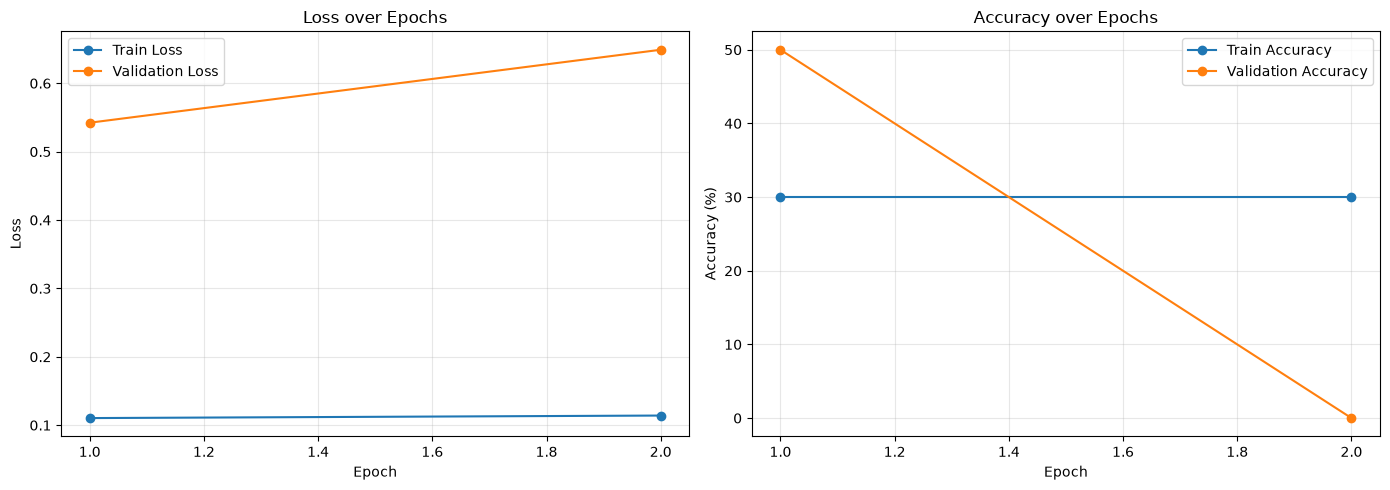

Final Train Loss: 0.1141 | Final Train Accuracy: 30.0%
Final Validation Loss: 0.649 | Final Validation Accuracy: 0.0%
Best Validation Accuracy: 50.0% (Epoch 1)


In [17]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(total_train_loss_plot) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, total_train_loss_plot, label='Train Loss', marker='o')
axes[0].plot(epochs_range, total_val_loss_plot, label='Validation Loss', marker='o')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, total_train_acc_plot, label='Train Accuracy', marker='o')
axes[1].plot(epochs_range, total_val_acc_plot, label='Validation Accuracy', marker='o')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Train Loss: {total_train_loss_plot[-1]} | Final Train Accuracy: {total_train_acc_plot[-1]}%")
print(f"Final Validation Loss: {total_val_loss_plot[-1]} | Final Validation Accuracy: {total_val_acc_plot[-1]}%")
print(f"Best Validation Accuracy: {max(total_val_acc_plot)}% (Epoch {total_val_acc_plot.index(max(total_val_acc_plot)) + 1})")